In [1]:
# Training
import xarray as xr
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc

print(f"\n{'='*80}\n   1. LOADING ERA5 SST DATA\n{'='*80}")

ERA5_SST_PATH = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\sst.nc")

ds = xr.open_dataset(ERA5_SST_PATH, engine="h5netcdf")

print(ds)

if 'latitude' in ds.coords:
    ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})

possible_sst_names = ['sst', 'sea_surface_temperature']

for var in possible_sst_names:
    if var in ds.data_vars:
        sst_var = var
        break

print(f"Using SST variable: {sst_var}")

uk_box = ds[sst_var].sel(
    lat=slice(61, 49),
    lon=slice(-10, 2)
)

time_coord = 'valid_time'

sst_monthly = uk_box.resample({time_coord: '1ME'}).mean()

sst_monthly = sst_monthly - 273.15

sst_monthly = sst_monthly.astype(np.float32)

print(f"SST monthly shape: {sst_monthly.shape}")

data_4d = np.expand_dims(sst_monthly.values, axis=-1)

print(f"\n{'='*80}\n   2. SCALING & SEQUENCE GENERATION\n{'='*80}")

data_scaled = np.zeros_like(data_4d, dtype=np.float32)

mean_val = np.nanmean(data_4d)
std_val = np.nanstd(data_4d)

scaler = {'mean': mean_val, 'std': std_val}

data_scaled = (data_4d - mean_val) / (std_val + 1e-8)
data_scaled = np.nan_to_num(data_scaled, nan=0.0)

lookback = 12

X, y = [], []

for i in range(data_scaled.shape[0] - lookback):
    X.append(data_scaled[i:i+lookback])
    y.append(data_scaled[i+lookback])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

del data_scaled
gc.collect()

print(f"\n{'='*80}\n   3. CHRONOLOGICAL TRAIN / VAL / TEST SPLIT\n{'='*80}")

train_split = int(X.shape[0] * 0.70)
val_split = int(X.shape[0] * 0.85)

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]
X_test, y_test = X[val_split:], y[val_split:]

times = pd.to_datetime(sst_monthly[time_coord].values)
target_times = times[lookback:]

train_times = target_times[:train_split]
val_times = target_times[train_split:val_split]
test_times = target_times[val_split:]

print(f" TRAINING SET   : {train_times[0]} to {train_times[-1]}")
print(f" VALIDATION SET : {val_times[0]} to {val_times[-1]}")
print(f" TESTING SET    : {test_times[0]} to {test_times[-1]}")

print(f"\n{'='*80}\n   4. CONVLSTM TRAINING\n{'='*80}")

_, time_steps, n_lat, n_lon, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        32,
        (3, 3),
        padding='same',
        return_sequences=True,
        input_shape=(time_steps, n_lat, n_lon, n_features)
    ),
    BatchNormalization(),

    ConvLSTM2D(
        32,
        (3, 3),
        padding='same',
        return_sequences=True
    ),
    BatchNormalization(),

    ConvLSTM2D(
        16,
        (3, 3),
        padding='same',
        return_sequences=False
    ),
    BatchNormalization(),

    Conv2D(
        1,
        (3, 3),
        activation='linear',
        padding='same'
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        'best_sst_convlstm.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining Complete.")


   1. LOADING ERA5 SST DATA
<xarray.Dataset> Size: 491MB
Dimensions:     (valid_time: 1034, latitude: 361, longitude: 329)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2026-02-01
  * latitude    (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 3kB -80.0 -79.75 -79.5 ... 1.5 1.75 2.0
    expver      (valid_time) <U4 17kB ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 491MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-24T15:55 GRIB to CDM+CF via cfgrib-0.9.1...
Using SST variable: sst
SST monthly shape: (1034, 49, 49)

   2. SCALING & SEQUENCE GENERATION
X shape: (1022, 12, 49, 49, 1)


C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 49, 49, 32)      │          38,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 49, 49, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 49, 49, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 49, 49, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 49, 49, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 49, 49, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 49, 49, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,177 (547.57 KB)

 Trainable params: 140,017 (546.94 KB)

 Non-trainable params: 160 (640.00 B)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 128s 682ms/step - loss: 0.2715 - mae: 0.3834 - val_loss: 0.4554 - val_mae: 0.5196 - learning_rate: 0.0010
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 119s 663ms/step - loss: 0.1387 - mae: 0.2924 - val_loss: 0.2651 - val_mae: 0.3754 - learning_rate: 0.0010
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 120s 669ms/step - loss: 0.1147 - mae: 0.2661 - val_loss: 0.0805 - val_mae: 0.2025 - learning_rate: 0.0010
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 139s 654ms/step - loss: 0.0824 - mae: 0.2208 - val_loss: 0.1003 - val_mae: 0.2335 - learning_rate: 0.0010
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 120s 672ms/step - loss: 0.0703 - mae: 0.2024 - val_loss: 0.0631 - val_mae: 0.1933 - learning_rate: 0.0010

Training Complete.


In [2]:
# Forecasting
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

print(f"\n{'='*80}\n   FORECASTING & EVALUATION\n{'='*80}")

model = load_model('best_sst_convlstm.keras')

y_pred = model.predict(X_test)

y_pred_unscaled = (y_pred * scaler['std']) + scaler['mean']
y_test_unscaled = (y_test * scaler['std']) + scaler['mean']

mae = mean_absolute_error(
    y_test_unscaled.flatten(),
    y_pred_unscaled.flatten()
)

rmse = np.sqrt(mean_squared_error(
    y_test_unscaled.flatten(),
    y_pred_unscaled.flatten()
))

r2 = r2_score(
    y_test_unscaled.flatten(),
    y_pred_unscaled.flatten()
)

print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"R²   : {r2:.4f}")


   FORECASTING & EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
MAE  : 0.5561 °C
RMSE : 0.7412 °C
R²   : 0.9046


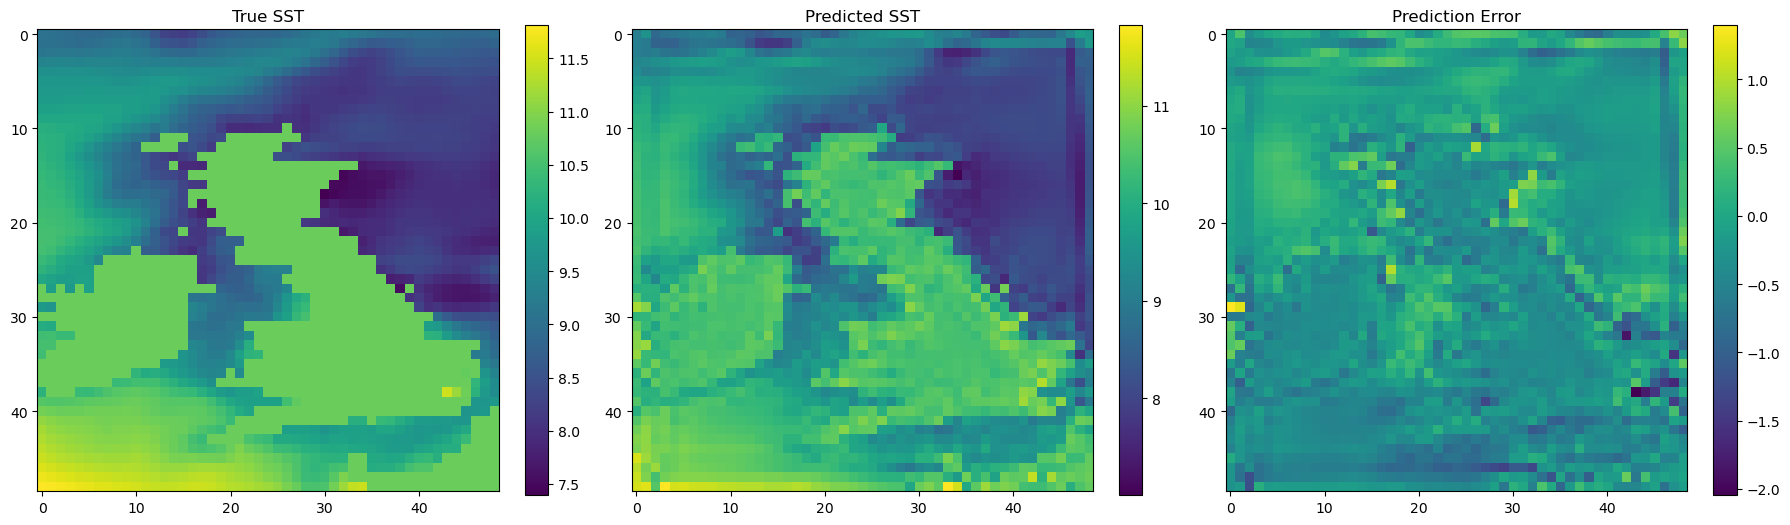

In [3]:
# Plots
sample_idx = 0

truth = y_test_unscaled[sample_idx, ..., 0]
pred = y_pred_unscaled[sample_idx, ..., 0]
error = pred - truth

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(truth)
axes[0].set_title("True SST")

im1 = axes[1].imshow(pred)
axes[1].set_title("Predicted SST")

im2 = axes[2].imshow(error)
axes[2].set_title("Prediction Error")

plt.colorbar(im0, ax=axes[0], fraction=0.046)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()